# Baseline No-RAG

Prompt-only baseline: run 5 example queries without retrieval and log token counts (approx.).

In [5]:
from pathlib import Path
import sys
import re, json, statistics

# Ensure project root is importable when running from notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.prompt import assemble_prompt
from src.generation.ollama_client import generate_raw

# Configure model name for local Ollama or compatible runtime
MODEL = 'gemma4:e2b'  # set to your model name, e.g. 'llama2' or 'ollama/your-model'

def approx_token_count(text: str) -> int:
    # lightweight token estimate: word-like tokens
    return len(re.findall(r'\w+|\S', text))

queries = [
    'What is the assessment weighting for CS101 (coursework, midterm, final)?',
    'When are the CS101 assignment deadlines and exam dates?',
    'Who is the course convenor for CS101 and how can I contact them?',
    'Where and when are CS101 lab sessions held?',
    'What is the CS101 convenor office hour schedule?'
]

results = []

In [6]:
# Always start from a clean run state
results = []
output_path = PROJECT_ROOT / 'notebooks' / 'baseline_no_rag_results.json'
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text('[]', encoding='utf8')

for qidx, query in enumerate(queries, start=1):
    prompt = assemble_prompt(
        role='Assistant for HKBU students',
        task=query,
        context_snippets=[],
        constraints=[
            'Be concise',
            'Use bullet points when helpful',
            'Return only the final answer and do not repeat the Task or prompt text',
        ],
        output_format='Plain text',
    )

    try:
        response = generate_raw(prompt, model=MODEL, temperature=0.2, num_predict=300)
    except Exception as e:
        response = f'__generation_error__: {e}'

    prompt_tokens = approx_token_count(prompt)
    response_tokens = approx_token_count(response)

    results.append({
        'query': query,
        'prompt': prompt,
        'response': response,
        'prompt_tokens': prompt_tokens,
        'response_tokens': response_tokens,
    })

# summary
total_prompt = sum(r['prompt_tokens'] for r in results)
total_response = sum(r['response_tokens'] for r in results)
print(f'Queries processed: {len(results)} / {len(queries)}')
print(f'Total prompt tokens (approx): {total_prompt}')
print(f'Total response tokens (approx): {total_response}')
print(f"Average response tokens: {statistics.mean([r['response_tokens'] for r in results]) if results else 0}")

with output_path.open('w', encoding='utf8') as fh:
    json.dump(results, fh, ensure_ascii=False, indent=2)
print(f'Results saved to: {output_path}')

Queries processed: 5 / 5
Total prompt tokens (approx): 282
Total response tokens (approx): 99
Average response tokens: 19.8
Results saved to: c:\Users\user\Desktop\prompt-engin-proj\notebooks\baseline_no_rag_results.json


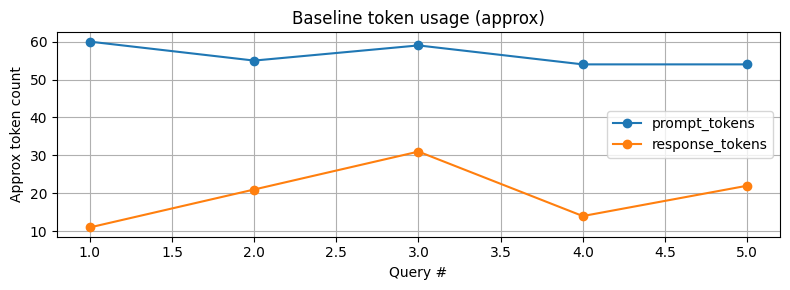

In [7]:
import matplotlib.pyplot as plt
prompt_tokens = [r['prompt_tokens'] for r in results]
response_tokens = [r['response_tokens'] for r in results]
indices = list(range(1, len(results)+1))
plt.figure(figsize=(8,3))
plt.plot(indices, prompt_tokens, marker='o', label='prompt_tokens')
plt.plot(indices, response_tokens, marker='o', label='response_tokens')
plt.xlabel('Query #')
plt.ylabel('Approx token count')
plt.title('Baseline token usage (approx)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()